In [1]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
from rdkit import Chem
import matplotlib.pyplot as plt

# 加路径，方便 import scripts 里的模块
sys.path.insert(0, os.path.abspath('../scripts'))

# 用 exec 加载你已有的函数
script_dir = os.path.abspath('../scripts')
exec(open(os.path.join(script_dir, '04_graph_utils.py'), encoding='utf-8').read())
exec(open(os.path.join(script_dir, '05_diffusion.py'), encoding='utf-8').read())
exec(open(os.path.join(script_dir, '06_graph_decoder.py'), encoding='utf-8').read())

print("模块加载完成")

模块加载完成


In [2]:
def load_smiles(path):
    valid = []
    with open(path, 'r') as f:
        for line in f:
            smi = line.strip()
            if smi and Chem.MolFromSmiles(smi):
                valid.append(smi)
    print(f"有效 SMILES: {len(valid)} 条")
    return valid

smiles_list = load_smiles('../data/smiles_2k.txt')
smiles_list[:5]

有效 SMILES: 2000 条


['CCCS(=O)c1ccc2[nH]c(=NC(=O)OC)[nH]c2c1',
 'CC(C)(C)C(=O)C(Oc1ccc(Cl)cc1)n1ccnc1',
 'CC1C2CCC(C2)C1CN(CCO)C(=O)c1ccc(Cl)cc1',
 'Cc1c(Cl)cccc1Nc1ncccc1C(=O)OCC(O)CO',
 'Cn1cnc2c1c(=O)n(CC(O)CO)c(=O)n2C']

In [3]:
# 第3个单元格：预处理
all_data = []
failed = 0
for i, smi in enumerate(smiles_list):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        failed += 1
        continue
    A0, atom_symbols = build_adj(mol)
    fp = get_fingerprint(mol)
    atom_types = get_atom_one_hot(atom_symbols)
    A0_labels = np.argmax(A0, axis=-1)
    all_data.append({
        'A0': A0,
        'A0_labels': A0_labels,
        'atom_types': atom_types,
        'fp': fp,
    })
    if i % 500 == 0:
        print(f"  处理中... {i}/{len(smiles_list)}")

print(f"预处理完成: {len(all_data)} 个分子")
print(f"失败的: {failed}")

# 看看第1个分子的形状
d = all_data[0]
print(f"A0 形状: {d['A0'].shape}")
print(f"原子类型形状: {d['atom_types'].shape}")
print(f"指纹长度: {d['fp'].shape}")

  处理中... 0/2000
  处理中... 500/2000
  处理中... 1000/2000
  处理中... 1500/2000
预处理完成: 2000 个分子
失败的: 0
A0 形状: (19, 19, 5)
原子类型形状: (19, 10)
指纹长度: (2048,)


In [4]:
# 模型（用你在 06 里定义的 edge_denoiser）
optimizer = torch.optim.Adam(edge_denoiser.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()
alpha_bars = get_noise_schedule(500)

print(f"模型参数量: {sum(p.numel() for p in edge_denoiser.parameters())}")

模型参数量: 1194501


In [5]:
num_epochs = 10
loss_history = []

for epoch in range(num_epochs):
    total_loss = 0.0
    for data in all_data:
        t = sample_timesteps(1, 500)[0]
        At = q_sample(data['A0'].copy(), t, alpha_bars)
        features = build_init_feature(data['atom_types'], At, data['fp'])
        i_idx, j_idx = np.triu_indices(data['A0'].shape[0], k=1)
        targets = data['A0_labels'][i_idx, j_idx]

        logits = edge_denoiser(torch.tensor(features))
        loss = loss_fn(logits, torch.tensor(targets, dtype=torch.long))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(all_data)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1:2d}/{num_epochs}, loss = {avg_loss:.4f}")

Epoch  1/10, loss = 0.4385
Epoch  2/10, loss = 0.3487
Epoch  3/10, loss = 0.3396
Epoch  4/10, loss = 0.3288
Epoch  5/10, loss = 0.3265
Epoch  6/10, loss = 0.3233
Epoch  7/10, loss = 0.3191
Epoch  8/10, loss = 0.3166
Epoch  9/10, loss = 0.3181
Epoch 10/10, loss = 0.3132


In [6]:
def evaluate_validity(all_data, num_samples=100):
    """从 all_data 里取前 num_samples 个分子，用模型生成后检查合法性"""
    valid_count = 0
    alpha_bars = get_noise_schedule(500)

    for i in range(min(num_samples, len(all_data))):
        data = all_data[i]
        n = data['A0'].shape[0]

        # 从纯随机噪声开始
        At = np.zeros((n, n, 5), dtype=np.float32)
        np.fill_diagonal(At[:, :, 0], 1)  # 对角线无键

        # 逐步去噪（从 T-1 到 0）
        for t in range(499, -1, -1):
            features = build_init_feature(data['atom_types'], At, data['fp'])
            logits = edge_denoiser(torch.tensor(features))
            preds = torch.argmax(logits, dim=1).numpy()

            # 把预测的边填回 At
            i_idx, j_idx = np.triu_indices(n, k=1)
            At_new = np.zeros_like(At)
            np.fill_diagonal(At_new[:, :, 0], 1)
            for k in range(len(i_idx)):
                At_new[i_idx[k], j_idx[k], preds[k]] = 1
                At_new[j_idx[k], i_idx[k], preds[k]] = 1
            At = At_new

        # 检查生成的分子是否合法
        atom_symbols_list = []
        for ai in range(n):
            for sym, idx in atom_maps.items():
                if data['atom_types'][ai, idx] == 1:
                    atom_symbols_list.append(sym)
                    break

        mol = adj_to_mol(atom_symbols_list, At)
        if mol is not None:
            valid_count += 1

    validity = valid_count / min(num_samples, len(all_data))
    return validity

In [7]:
num_epochs = 50
loss_history = []
validity_history = []

for epoch in range(num_epochs):
    total_loss = 0.0
    for data in all_data:
        t = sample_timesteps(1, 500)[0]
        At = q_sample(data['A0'].copy(), t, alpha_bars)
        features = build_init_feature(data['atom_types'], At, data['fp'])
        i_idx, j_idx = np.triu_indices(data['A0'].shape[0], k=1)
        targets = data['A0_labels'][i_idx, j_idx]

        logits = edge_denoiser(torch.tensor(features))
        loss = loss_fn(logits, torch.tensor(targets, dtype=torch.long))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(all_data)
    loss_history.append(avg_loss)

    # 每 10 轮评估 validity
    if epoch % 10 == 0 or epoch == num_epochs - 1:
        val = evaluate_validity(all_data, num_samples=50)
        validity_history.append((epoch, val))
        print(f"Epoch {epoch+1:2d}/{num_epochs}, loss = {avg_loss:.4f}, validity = {val:.2%}")
    else:
        print(f"Epoch {epoch+1:2d}/{num_epochs}, loss = {avg_loss:.4f}")

Epoch  1/50, loss = 0.3109, validity = 100.00%
Epoch  2/50, loss = 0.3109
Epoch  3/50, loss = 0.3131
Epoch  4/50, loss = 0.3101
Epoch  5/50, loss = 0.3072
Epoch  6/50, loss = 0.3058
Epoch  7/50, loss = 0.3118
Epoch  8/50, loss = 0.3081
Epoch  9/50, loss = 0.3049
Epoch 10/50, loss = 0.3065
Epoch 11/50, loss = 0.3069, validity = 100.00%
Epoch 12/50, loss = 0.3032
Epoch 13/50, loss = 0.3060
Epoch 14/50, loss = 0.3024
Epoch 15/50, loss = 0.3027
Epoch 16/50, loss = 0.3059
Epoch 17/50, loss = 0.3046
Epoch 18/50, loss = 0.3077
Epoch 19/50, loss = 0.3037
Epoch 20/50, loss = 0.3048


[16:12:41] non-ring atom 1 marked aromatic


分子不合法:non-ring atom 1 marked aromatic
Epoch 21/50, loss = 0.3024, validity = 98.00%
Epoch 22/50, loss = 0.3016
Epoch 23/50, loss = 0.3031
Epoch 24/50, loss = 0.2974
Epoch 25/50, loss = 0.3017
Epoch 26/50, loss = 0.3068
Epoch 27/50, loss = 0.3054
Epoch 28/50, loss = 0.3005
Epoch 29/50, loss = 0.3059
Epoch 30/50, loss = 0.3023


[16:20:02] non-ring atom 15 marked aromatic


分子不合法:non-ring atom 15 marked aromatic


...

分子不合法:Explicit valence for atom # 15 N, 6, is greater than permitted


[16:44:36] non-ring atom 1 marked aromatic


分子不合法:non-ring atom 1 marked aromatic


[16:44:38] non-ring atom 11 marked aromatic


分子不合法:non-ring atom 11 marked aromatic
Epoch 50/50, loss = 0.2981, validity = 92.00%


<Figure size 640x480 with 0 Axes>

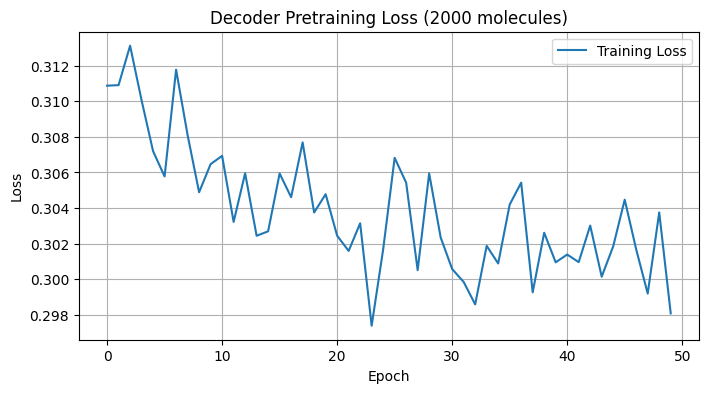

Day 8 完成：loss 曲线、日志、模型均已保存


In [9]:
os.makedirs('../images/DAY8', exist_ok=True)
plt.savefig('../images/DAY8/loss_curve.png', dpi=150, bbox_inches='tight')
# 画 loss 曲线
plt.figure(figsize=(8, 4))
plt.plot(loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Decoder Pretraining Loss (2000 molecules)')
plt.legend()
plt.grid(True)
plt.savefig('../images/DAY8/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# 保存日志
import csv
os.makedirs('../logs', exist_ok=True)
with open('../logs/day8_pretrain_log.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'loss', 'validity'])
    for i, loss in enumerate(loss_history):
        val_found = [v for e, v in validity_history if e == i]
        val = val_found[0] if val_found else ''
        writer.writerow([i+1, f'{loss:.4f}', val])

# 保存模型
torch.save(edge_denoiser.state_dict(), '../checkpoints/edge_denoiser_2000.pth')
print("Day 8 完成：loss 曲线、日志、模型均已保存")